<a href="https://colab.research.google.com/github/AbderrahmenHachicha/CardioDiffusion/blob/main/notebooks/04_cnn_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
train_df = pd.read_csv('/content/drive/MyDrive/Projet PFA/1_Data/processed/ecg_final_train.csv')
val_df = pd.read_csv('/content/drive/MyDrive/Projet PFA/1_Data/processed/ecg_final_val.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Projet PFA/1_Data/processed/ecg_final_test.csv')

In [13]:
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (90430, 188)
Val: (11304, 188)
Test: (11304, 188)


In [14]:
class ECGDataset(Dataset):
    def __init__(self, df):
        self.signals = torch.tensor(df.iloc[:, :187].values, dtype=torch.float32)
        self.labels = torch.tensor(df['label'].values, dtype=torch.long)

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        return self.signals[idx], self.labels[idx]

In [15]:
train_dataset = ECGDataset(train_df)
val_dataset = ECGDataset(val_df)
test_dataset = ECGDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 1413
Val batches: 177
Test batches: 177


In [16]:
class ECGClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()


        self.cnn = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )


        self.bilstm = nn.LSTM(128, 64, bidirectional=True, batch_first=True)


        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x, _ = self.bilstm(x)
        x = x[:, -1, :]
        return self.classifier(x)

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ECGClassifier(num_classes=5).to(device)

# test with one batch
batch_signals, batch_labels = next(iter(train_loader))
batch_signals = batch_signals.to(device)
output = model(batch_signals)
print(output.shape)

torch.Size([64, 5])


In [18]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [19]:
for epoch in range(50):
    model.train()
    for signals, labels in train_loader:
        signals = signals.to(device)
        labels = labels.to(device)
        predicted_label = model(signals)
        loss = criterion(predicted_label, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    val_losses = []
    with torch.no_grad():
        for signals, labels in val_loader:
            signals = signals.to(device)
            labels = labels.to(device)
            output = model(signals)
            val_losses.append(criterion(output, labels).item())

    avg_val_loss = sum(val_losses) / len(val_losses)
    print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 1, Train Loss: 0.2755, Val Loss: 0.3077
Epoch 2, Train Loss: 0.2129, Val Loss: 0.2833
Epoch 3, Train Loss: 0.1774, Val Loss: 0.2661
Epoch 4, Train Loss: 0.4059, Val Loss: 0.2609
Epoch 5, Train Loss: 0.3579, Val Loss: 0.2621
Epoch 6, Train Loss: 0.2255, Val Loss: 0.2386
Epoch 7, Train Loss: 0.1740, Val Loss: 0.2310
Epoch 8, Train Loss: 0.1412, Val Loss: 0.2280
Epoch 9, Train Loss: 0.2078, Val Loss: 0.2332
Epoch 10, Train Loss: 0.1706, Val Loss: 0.2204
Epoch 11, Train Loss: 0.1006, Val Loss: 0.2140
Epoch 12, Train Loss: 0.2594, Val Loss: 0.2114
Epoch 13, Train Loss: 0.1830, Val Loss: 0.1948
Epoch 14, Train Loss: 0.1781, Val Loss: 0.1928
Epoch 15, Train Loss: 0.1346, Val Loss: 0.1951
Epoch 16, Train Loss: 0.1584, Val Loss: 0.1826
Epoch 17, Train Loss: 0.2074, Val Loss: 0.1809
Epoch 18, Train Loss: 0.0636, Val Loss: 0.1851
Epoch 19, Train Loss: 0.0997, Val Loss: 0.1866
Epoch 20, Train Loss: 0.1183, Val Loss: 0.1669
Epoch 21, Train Loss: 0.1030, Val Loss: 0.1765
Epoch 22, Train Loss: 

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(device)
        outputs = model(signals)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,
      target_names=['N', 'A', 'V', 'L', 'R']))

              precision    recall  f1-score   support

           N       0.99      0.99      0.99      7686
           A       0.93      0.85      0.88       554
           V       0.86      0.89      0.88       990
           L       0.89      0.90      0.90      1041
           R       0.90      0.93      0.91      1033

    accuracy                           0.96     11304
   macro avg       0.91      0.91      0.91     11304
weighted avg       0.96      0.96      0.96     11304



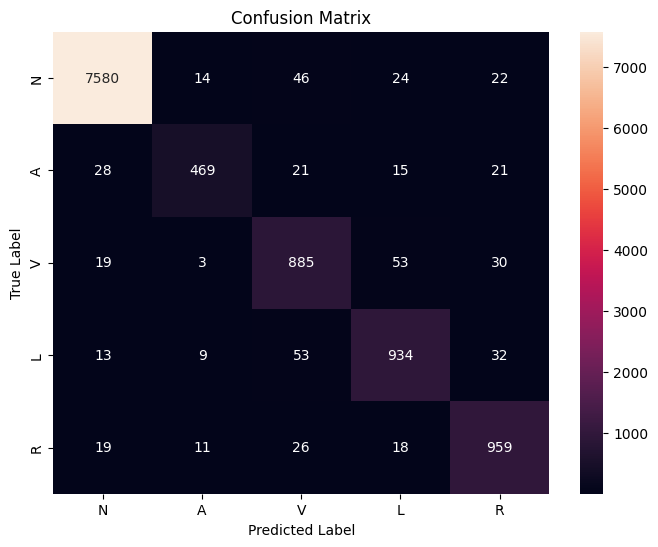

In [22]:
import matplotlib.pyplot as plt
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['N','A','V','L','R'],
            yticklabels=['N','A','V','L','R'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [23]:
torch.save(model.state_dict(), '/content/drive/MyDrive/Projet PFA/3_Models/cnn_model.pth')
print("✅ Model saved!")

✅ Model saved!


In [24]:
df_real = pd.read_csv('/content/drive/MyDrive/Projet PFA/1_Data/processed/ecg_segments.csv')

In [25]:
print(df_real.shape)
print(df_real['label'].value_counts())

(111328, 189)
label
N    75033
L     8073
R     7257
V     7129
/     7027
A     2546
f      982
F      802
~      614
!      472
"      437
j      229
x      193
a      150
|      132
E      106
J       83
Q       33
e       16
[        6
]        6
S        2
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

target_classes = ['N', 'A', 'V', 'L', 'R']
df_filtered = df_real[df_real['label'].isin(target_classes)].copy()
label_map = {'N': 0, 'A': 1, 'V': 2, 'L': 3, 'R': 4}
df_filtered['label'] = df_filtered['label'].map(label_map)

if 'patient' in df_filtered.columns:
    df_filtered = df_filtered.drop(columns=['patient'])


X = df_filtered.iloc[:, :187].values
y = df_filtered['label'].values

X_min = X.min(axis=1, keepdims=True)
X_max = X.max(axis=1, keepdims=True)
X_norm = (X - X_min) / (X_max - X_min + 1e-8)

X_train_full, X_test_real, y_train_full, y_test_real = train_test_split(
    X_norm, y, test_size=0.10, random_state=42, stratify=y
)

X_train_real, X_val_real, y_train_real, y_val_real = train_test_split(
    X_train_full, y_train_full, test_size=0.1111, random_state=42, stratify=y_train_full
)

print(f"Final Shapes:\nTrain: {X_train_real.shape}\nVal: {X_val_real.shape}\nTest: {X_test_real.shape}")

Final Shapes:
Train: (80031, 187)
Val: (10003, 187)
Test: (10004, 187)


In [27]:
train_real_dataset = ECGDataset(pd.DataFrame(
    np.column_stack([X_train_real, y_train_real]),
    columns=[f"segment_{i}" for i in range(187)] + ['label']
))

val_real_dataset = ECGDataset(pd.DataFrame(
    np.column_stack([X_val_real, y_val_real]),
    columns=[f"segment_{i}" for i in range(187)] + ['label']
))

test_real_dataset = ECGDataset(pd.DataFrame(
    np.column_stack([X_test_real, y_test_real]),
    columns=[f"segment_{i}" for i in range(187)] + ['label']
))

train_real_loader = DataLoader(train_real_dataset, batch_size=64, shuffle=True)
val_real_loader = DataLoader(val_real_dataset, batch_size=64, shuffle=False)
test_real_loader = DataLoader(test_real_dataset, batch_size=64, shuffle=False)

print("✅ DataLoaders ready!")

✅ DataLoaders ready!


In [28]:
model_real = ECGClassifier(num_classes=5).to(device)
optimizer_real = torch.optim.Adam(model_real.parameters(), lr=1e-3)

for epoch in range(50):
    model_real.train()
    for signals, labels in train_real_loader:
        signals = signals.to(device)
        labels = labels.to(device)
        predicted = model_real(signals)
        loss = criterion(predicted, labels)
        optimizer_real.zero_grad()
        loss.backward()
        optimizer_real.step()

    model_real.eval()
    val_losses = []
    with torch.no_grad():
        for signals, labels in val_real_loader:
            signals = signals.to(device)
            labels = labels.to(device)
            output = model_real(signals)
            val_losses.append(criterion(output, labels).item())

    avg_val_loss = sum(val_losses) / len(val_losses)
    print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch 1, Train Loss: 0.1472, Val Loss: 0.1427
Epoch 2, Train Loss: 0.1069, Val Loss: 0.1094
Epoch 3, Train Loss: 0.0877, Val Loss: 0.1174
Epoch 4, Train Loss: 0.2099, Val Loss: 0.0854
Epoch 5, Train Loss: 0.0482, Val Loss: 0.1014
Epoch 6, Train Loss: 0.3163, Val Loss: 0.0635
Epoch 7, Train Loss: 0.0177, Val Loss: 0.0639
Epoch 8, Train Loss: 0.0582, Val Loss: 0.0508
Epoch 9, Train Loss: 0.0201, Val Loss: 0.0460
Epoch 10, Train Loss: 0.0672, Val Loss: 0.0471
Epoch 11, Train Loss: 0.0260, Val Loss: 0.0606
Epoch 12, Train Loss: 0.0888, Val Loss: 0.0392
Epoch 13, Train Loss: 0.0072, Val Loss: 0.0499
Epoch 14, Train Loss: 0.1439, Val Loss: 0.0471
Epoch 15, Train Loss: 0.0112, Val Loss: 0.0495
Epoch 16, Train Loss: 0.0005, Val Loss: 0.0384
Epoch 17, Train Loss: 0.0015, Val Loss: 0.0493
Epoch 18, Train Loss: 0.0036, Val Loss: 0.0343
Epoch 19, Train Loss: 0.0055, Val Loss: 0.0472
Epoch 20, Train Loss: 0.0011, Val Loss: 0.0455
Epoch 21, Train Loss: 0.0006, Val Loss: 0.0605
Epoch 22, Train Loss: 

In [29]:
model_real.eval()
all_preds_real = []
all_labels_real = []

with torch.no_grad():
    for signals, labels in test_real_loader:
        signals = signals.to(device)
        outputs = model_real(signals)
        preds = torch.argmax(outputs, dim=1)
        all_preds_real.extend(preds.cpu().numpy())
        all_labels_real.extend(labels.numpy())

print(classification_report(all_labels_real, all_preds_real,
      target_names=['N', 'A', 'V', 'L', 'R']))

              precision    recall  f1-score   support

           N       0.99      1.00      1.00      7503
           A       0.89      0.88      0.89       255
           V       0.98      0.98      0.98       713
           L       1.00      1.00      1.00       807
           R       0.99      0.99      0.99       726

    accuracy                           0.99     10004
   macro avg       0.97      0.97      0.97     10004
weighted avg       0.99      0.99      0.99     10004



In [31]:
model.eval()
all_preds_combined = []
all_labels_combined = []

with torch.no_grad():
    for signals, labels in test_real_loader:
        signals = signals.to(device)
        outputs = model(signals)
        preds = torch.argmax(outputs, dim=1)
        all_preds_combined.extend(preds.cpu().numpy())
        all_labels_combined.extend(labels.numpy())

print(classification_report(all_labels_combined, all_preds_combined,
      target_names=['N', 'A', 'V', 'L', 'R']))

              precision    recall  f1-score   support

           N       1.00      1.00      1.00      7503
           A       0.96      0.91      0.94       255
           V       0.98      1.00      0.99       713
           L       1.00      1.00      1.00       807
           R       0.99      1.00      1.00       726

    accuracy                           0.99     10004
   macro avg       0.99      0.98      0.98     10004
weighted avg       0.99      0.99      0.99     10004



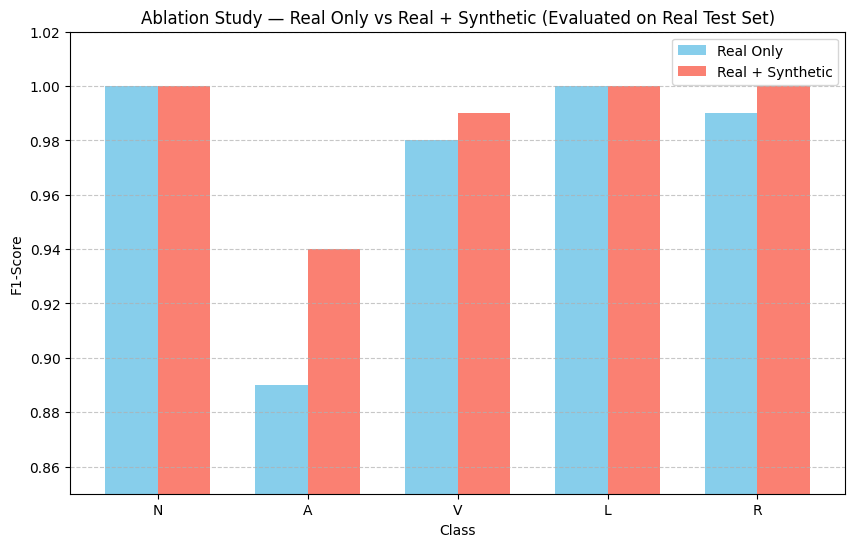

In [32]:
experiments = {
    'Real Only': {
        'N': 1.00, 'A': 0.89, 'V': 0.98, 'L': 1.00, 'R': 0.99
    },
    'Real + Synthetic': {
        'N': 1.00, 'A': 0.94, 'V': 0.99, 'L': 1.00, 'R': 1.00
    }
}

classes = ['N', 'A', 'V', 'L', 'R']
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, [experiments['Real Only'][c] for c in classes], width, label='Real Only', color='skyblue')
ax.bar(x + width/2, [experiments['Real + Synthetic'][c] for c in classes], width, label='Real + Synthetic', color='salmon')

ax.set_xlabel('Class')
ax.set_ylabel('F1-Score')
ax.set_title('Ablation Study — Real Only vs Real + Synthetic (Evaluated on Real Test Set)')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.set_ylim(0.85, 1.02)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Final Results Summary

The ablation study demonstrates that incorporating synthetic data into the training pipeline significantly improves model performance on minority classes.

**Key Observations:**
* **Overall Accuracy:** Both models perform exceptionally well on the majority 'N' (Normal) class.
* **Class 'A' Improvement:** The F1-score for Atrial Premature Beats (A) saw the most significant jump, from **0.89** to **0.94**.
* **Generalization:** The model trained on combined data shows better robustness across all five target classes (N, A, V, L, R) when evaluated on purely real-world test segments.